In [1]:
import tensorflow.keras.utils as conv_utils
from __future__ import print_function
from __future__ import absolute_import
from __future__ import division
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Reshape,Lambda
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, UpSampling2D
from tensorflow.keras.layers import AveragePooling2D, MaxPooling2D,GlobalAveragePooling2D,GlobalMaxPooling2D
import numpy as np
import warnings
from keras.layers import Input
from tensorflow.keras.layers import concatenate  # For concatenation
from tensorflow.keras.layers import add          # For addition
from tensorflow.keras.layers import BatchNormalization, LayerNormalization
from keras.regularizers import l2
from tensorflow.python.keras.utils.layer_utils import convert_dense_weights_data_format
from tensorflow.keras.utils import get_file
from tensorflow.keras.utils import get_source_inputs
from tensorflow.keras.applications.imagenet_utils import decode_predictions
import keras.backend as K
from keras_applications.imagenet_utils import _obtain_input_shape

__all__ = ['DualPathNetwork', 'DPN92', 'DPN98', 'DPN137', 'DPN107', 'preprocess_input', 'decode_predictions']


def preprocess_input(x, data_format=None):
    """Preprocesses a tensor encoding a batch of images.
       Obtained from https://github.com/cypw/DPNs

        # Arguments
            x: input Numpy tensor, 4D.
            data_format: data format of the image tensor.

        # Returns
            Preprocessed tensor.
        """
    if data_format is None:
        data_format = K.image_data_format()
    assert data_format in {'channels_last', 'channels_first'}

    if data_format == 'channels_first':
        # 'RGB'->'BGR'
        x = x[:, ::-1, :, :]
        # Zero-center by mean pixel
        x[:, 0, :, :] -= 104
        x[:, 1, :, :] -= 117
        x[:, 2, :, :] -= 128
    else:
        # 'RGB'->'BGR'
        x = x[:, :, :, ::-1]
        # Zero-center by mean pixel
        x[:, :, :, 0] -= 104
        x[:, :, :, 1] -= 117
        x[:, :, :, 2] -= 124

    x *= 0.0167
    return x


def DualPathNetwork(input_shape=None,
                    initial_conv_filters=64,
                    depth=[3, 4, 20, 3],
                    filter_increment=[16, 32, 24, 128],
                    cardinality=32,
                    width=3,
                    weight_decay=0,
                    include_top=True,
                    weights=None,
                    input_tensor=None,
                    pooling=None,
                    classes=1000):
    """ Instantiate the Dual Path Network architecture for the ImageNet dataset. Note that ,
        when using TensorFlow for best performance you should set
        `image_data_format="channels_last"` in your Keras config
        at ~/.keras/keras.json.
        The model are compatible with both
        TensorFlow and Theano. The dimension ordering
        convention used by the model is the one
        specified in your Keras config file.
        # Arguments
            initial_conv_filters: number of features for the initial convolution
            depth: number or layers in the each block, defined as a list.
                DPN-92  = [3, 4, 20, 3]
                DPN-98  = [3, 6, 20, 3]
                DPN-131 = [4, 8, 28, 3]
                DPN-107 = [4, 8, 20, 3]
            filter_increment: number of filters incremented per block, defined as a list.
                DPN-92  = [16, 32, 24, 128]
                DON-98  = [16, 32, 32, 128]
                DPN-131 = [16, 32, 32, 128]
                DPN-107 = [20, 64, 64, 128]
            cardinality: the size of the set of transformations
            width: width multiplier for the network
            weight_decay: weight decay (l2 norm)
            include_top: whether to include the fully-connected
                layer at the top of the network.
            weights: `None` (random initialization) or `imagenet` (trained
                on ImageNet)
            input_tensor: optional Keras tensor (i.e. output of `layers.Input()`)
                to use as image input for the model.
            input_shape: optional shape tuple, only to be specified
                if `include_top` is False (otherwise the input shape
                has to be `(224, 224, 3)` (with `tf` dim ordering)
                or `(3, 224, 224)` (with `th` dim ordering).
                It should have exactly 3 inputs channels,
                and width and height should be no smaller than 8.
                E.g. `(200, 200, 3)` would be one valid value.
            pooling: Optional pooling mode for feature extraction
                when `include_top` is `False`.
                - `None` means that the output of the model will be
                    the 4D tensor output of the
                    last convolutional layer.
                - `avg` means that global average pooling
                    will be applied to the output of the
                    last convolutional layer, and thus
                    the output of the model will be a 2D tensor.
                - `max` means that global max pooling will
                    be applied.
                - `max-avg` means that both global average and global max
                    pooling will be applied to the output of the last
                    convolution layer
            classes: optional number of classes to classify images
                into, only to be specified if `include_top` is True, and
                if no `weights` argument is specified.
        # Returns
            A Keras model instance.
        """

    if weights not in {'imagenet', None}:
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization) or `imagenet` '
                         '(pre-training on ImageNet).')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as imagenet with `include_top`'
                         ' as true, `classes` should be 1000')

    assert len(depth) == len(filter_increment), "The length of filter increment list must match the length " \
                                                "of the depth list."

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=224,
                                      min_size=32,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    x = _create_dpn(classes, img_input, include_top, initial_conv_filters,
                    filter_increment, depth, cardinality, width, weight_decay, pooling)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input
    # Create model.
    model = Model(inputs, x, name='resnext')

    # load weights

    return model


def DPN92(input_shape=None,
          include_top=True,
          weights=None,
          input_tensor=None,
          pooling=None,
          classes=1000):
    return DualPathNetwork(input_shape, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN98(input_shape=None,
          include_top=True,
          weights=None,
          input_tensor=None,
          pooling=None,
          classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=96, depth=[3, 6, 20, 3], filter_increment=[16, 32, 32, 128],
                           cardinality=40, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN137(input_shape=None,
           include_top=True,
           weights=None,
           input_tensor=None,
           pooling=None,
           classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=128, depth=[4, 8, 28, 3], filter_increment=[16, 32, 32, 128],
                           cardinality=40, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN107(input_shape=None,
           include_top=True,
           weights=None,
           input_tensor=None,
           pooling=None,
           classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=128, depth=[4, 8, 20, 3], filter_increment=[20, 64, 64, 128],
                           cardinality=50, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def _initial_conv_block_inception(input, initial_conv_filters, weight_decay=5e-4):
    ''' Adds an initial conv block, with batch norm and relu for the DPN
    Args:
        input: input tensor
        initial_conv_filters: number of filters for initial conv block
        weight_decay: weight decay factor
    Returns: a keras tensor
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = Conv2D(initial_conv_filters, (7, 7), padding='same', use_bias=False, kernel_initializer='he_normal',
               kernel_regularizer=l2(weight_decay), strides=(2, 2))(input)
    x = BatchNormalization(axis=channel_axis)(x)
    x = Activation('relu')(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    return x


def _bn_relu_conv_block(input, filters, kernel=(3, 3), stride=(1, 1), weight_decay=5e-4):
    ''' Adds a Batchnorm-Relu-Conv block for DPN
    Args:
        input: input tensor
        filters: number of output filters
        kernel: convolution kernel size
        stride: stride of convolution
    Returns: a keras tensor
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = Conv2D(filters, kernel, padding='same', use_bias=False, kernel_initializer='he_normal',
               kernel_regularizer=l2(weight_decay), strides=stride)(input)
    x = BatchNormalization(axis=channel_axis)(x)
    x = Activation('relu')(x)
    return x


def _grouped_convolution_block(input, grouped_channels, cardinality, strides, weight_decay=5e-4):
    ''' Adds a grouped convolution block. It is an equivalent block from the paper
    Args:
        input: input tensor
        grouped_channels: grouped number of filters
        cardinality: cardinality factor describing the number of groups
        strides: performs strided convolution for downscaling if > 1
        weight_decay: weight decay term
    Returns: a keras tensor
    '''
    init = input
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    group_list = []

    if cardinality == 1:
        # with cardinality 1, it is a standard convolution
        x = Conv2D(grouped_channels, (3, 3), padding='same', use_bias=False, strides=strides,
                   kernel_initializer='he_normal', kernel_regularizer=l2(weight_decay))(init)
        x = BatchNormalization(axis=channel_axis)(x)
        x = Activation('relu')(x)
        return x

    for c in range(cardinality):
        x = Lambda(lambda z: z[:, :, :, c * grouped_channels:(c + 1) * grouped_channels]
                   if K.image_data_format() == 'channels_last' else
                   lambda z: z[:, c * grouped_channels:(c + 1) * grouped_channels, :, :])(input)

        x = Conv2D(grouped_channels, (3, 3), padding='same', use_bias=False, strides=strides,
                   kernel_initializer='he_normal', kernel_regularizer=l2(weight_decay))(x)

        group_list.append(x)

    group_merge = concatenate(group_list, axis=channel_axis)
    group_merge = BatchNormalization(axis=channel_axis)(group_merge)
    group_merge = Activation('relu')(group_merge)
    return group_merge


def _dual_path_block(input, pointwise_filters_a, grouped_conv_filters_b, pointwise_filters_c,
                     filter_increment, cardinality, block_type='normal'):
    '''
    Creates a Dual Path Block. The first path is a ResNeXt type
    grouped convolution block. The second is a DenseNet type dense
    convolution block.

    Args:
        input: input tensor
        pointwise_filters_a: number of filters for the bottleneck
            pointwise convolution
        grouped_conv_filters_b: number of filters for the grouped
            convolution block
        pointwise_filters_c: number of filters for the bottleneck
            convolution block
        filter_increment: number of filters that will be added
        cardinality: cardinality factor
        block_type: determines what action the block will perform
            - `projection`: adds a projection connection
            - `downsample`: downsamples the spatial resolution
            - `normal`    : simple adds a dual path connection

    Returns: a list of two output tensors - one path of ResNeXt
        and another path for DenseNet

    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1
    grouped_channels = int(grouped_conv_filters_b / cardinality)

    init = concatenate(input, axis=channel_axis) if isinstance(input, list) else input

    if block_type == 'projection':
        stride = (1, 1)
        projection = True
    elif block_type == 'downsample':
        stride = (2, 2)
        projection = True
    elif block_type == 'normal':
        stride = (1, 1)
        projection = False
    else:
        raise ValueError('`block_type` must be one of ["projection", "downsample", "normal"]. Given %s' % block_type)

    if projection:
        projection_path = _bn_relu_conv_block(init, filters=pointwise_filters_c + 2 * filter_increment,
                                              kernel=(1, 1), stride=stride)
        input_residual_path = Lambda(lambda z: z[:, :, :, :pointwise_filters_c]
                                     if K.image_data_format() == 'channels_last' else
                                     z[:, :pointwise_filters_c, :, :])(projection_path)
        input_dense_path = Lambda(lambda z: z[:, :, :, pointwise_filters_c:]
                                  if K.image_data_format() == 'channels_last' else
                                  z[:, pointwise_filters_c:, :, :])(projection_path)
    else:
        input_residual_path = input[0]
        input_dense_path = input[1]

    x = _bn_relu_conv_block(init, filters=pointwise_filters_a, kernel=(1, 1))
    x = _grouped_convolution_block(x, grouped_channels=grouped_channels, cardinality=cardinality, strides=stride)
    x = _bn_relu_conv_block(x, filters=pointwise_filters_c + filter_increment, kernel=(1, 1))

    output_residual_path = Lambda(lambda z: z[:, :, :, :pointwise_filters_c]
                                  if K.image_data_format() == 'channels_last' else
                                  z[:, :pointwise_filters_c, :, :])(x)
    output_dense_path = Lambda(lambda z: z[:, :, :, pointwise_filters_c:]
                               if K.image_data_format() == 'channels_last' else
                               z[:, pointwise_filters_c:, :, :])(x)

    residual_path = add([input_residual_path, output_residual_path])
    dense_path = concatenate([input_dense_path, output_dense_path], axis=channel_axis)

    return [residual_path, dense_path]


def _create_dpn(nb_classes, img_input, include_top, initial_conv_filters,
                filter_increment, depth, cardinality=32, width=3, weight_decay=5e-4, pooling=None):
    ''' Creates a ResNeXt model with specified parameters
    Args:
        initial_conv_filters: number of features for the initial convolution
        include_top: Flag to include the last dense layer
        initial_conv_filters: number of features for the initial convolution
        filter_increment: number of filters incremented per block, defined as a list.
            DPN-92  = [16, 32, 24, 128]
            DON-98  = [16, 32, 32, 128]
            DPN-131 = [16, 32, 32, 128]
            DPN-107 = [20, 64, 64, 128]
        depth: number or layers in the each block, defined as a list.
            DPN-92  = [3, 4, 20, 3]
            DPN-98  = [3, 6, 20, 3]
            DPN-131 = [4, 8, 28, 3]
            DPN-107 = [4, 8, 20, 3]
        width: width multiplier for network
        weight_decay: weight_decay (l2 norm)
        pooling: Optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
            - `max-avg` means that both global average and global max
                pooling will be applied to the output of the last
                convolution layer
    Returns: a Keras Model
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1
    N = list(depth)
    base_filters = 256

    # block 1 (initial conv block)
    x = _initial_conv_block_inception(img_input, initial_conv_filters, weight_decay)

    # block 2 (projection block)
    filter_inc = filter_increment[0]
    filters = int(cardinality * width)

    x = _dual_path_block(x, pointwise_filters_a=filters,
                         grouped_conv_filters_b=filters,
                         pointwise_filters_c=base_filters,
                         filter_increment=filter_inc,
                         cardinality=cardinality,
                         block_type='projection')

    for i in range(N[0] - 1):
        x = _dual_path_block(x, pointwise_filters_a=filters,
                             grouped_conv_filters_b=filters,
                             pointwise_filters_c=base_filters,
                             filter_increment=filter_inc,
                             cardinality=cardinality,
                             block_type='normal')

    # remaining blocks
    for k in range(1, len(N)):
        print("BLOCK %d" % (k + 1))
        filter_inc = filter_increment[k]
        filters *= 2
        base_filters *= 2

        x = _dual_path_block(x, pointwise_filters_a=filters,
                             grouped_conv_filters_b=filters,
                             pointwise_filters_c=base_filters,
                             filter_increment=filter_inc,
                             cardinality=cardinality,
                             block_type='downsample')

        for i in range(N[k] - 1):
            x = _dual_path_block(x, pointwise_filters_a=filters,
                                 grouped_conv_filters_b=filters,
                                 pointwise_filters_c=base_filters,
                                 filter_increment=filter_inc,
                                 cardinality=cardinality,
                                 block_type='normal')

    x = concatenate(x, axis=channel_axis)

    if include_top:
        avg = GlobalAveragePooling2D()(x)
        max = GlobalMaxPooling2D()(x)
        x = add([avg, max])
        x = Lambda(lambda z: 0.5 * z)(x)
        x = Dense(nb_classes, use_bias=False, kernel_regularizer=l2(weight_decay),
                  kernel_initializer='he_normal', activation='softmax')(x)
    else:
        if pooling == 'avg':
            x = GlobalAveragePooling2D()(x)
        elif pooling == 'max':
            x = GlobalMaxPooling2D()(x)
        elif pooling == 'max-avg':
            a = GlobalMaxPooling2D()(x)
            b = GlobalAveragePooling2D()(x)
            x = add([a, b])
            x = Lambda(lambda z: 0.5 * z)(x)

    return x

if __name__ == '__main__':
    model = DPN92((224, 224, 3))

2024-05-14 14:41:46.237841: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-14 14:41:46.237910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-14 14:41:46.239412: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


BLOCK 2
BLOCK 3
BLOCK 4


In [2]:
model5 = DPN92(include_top=True,weights=None,input_tensor=None,input_shape=(64,64,3),
                              classes=13)
model5.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

BLOCK 2
BLOCK 3
BLOCK 4


In [26]:
model6 = DPN98(include_top=True,weights=None,input_tensor=None,input_shape=(64,64,3),
                              classes=13)
model6.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

BLOCK 2
BLOCK 3
BLOCK 4


In [ ]:
model7 = DPN107(include_top=True,weights=None,input_tensor=None,input_shape=(64,64,3),
                              classes=13)
model7.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model8 = DPN137(include_top=True,weights=None,input_tensor=None,input_shape=(64,64,3),
                              classes=13)
model8.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [3]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
import pickle
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot
from tensorflow.keras.layers import Lambda
from tensorflow.keras import backend as K
import keras
import random
import numpy as np
import os
from PIL import Image
from tensorflow.keras.utils import to_categorical

In [13]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for class_label, class_name in enumerate(sorted(os.listdir(folder))):
        class_folder = os.path.join(folder, class_name)
        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)
            img = Image.open(img_path)
            img = img.resize((64, 64))  
            img = np.array(img)
            if img is not None:
                images.append(img)
                labels.append(class_label)
    return np.array(images), np.array(labels)

# Assuming your dataset is stored in a folder called 'dataset'
dataset_folder = '/kaggle/input/paddydoctormedium'

# Load images and labels from the dataset folder
x_data, y_data = load_images_from_folder(dataset_folder)

# Shuffle the data
random_indices = np.random.permutation(len(x_data))
x_data = x_data[random_indices]
y_data = y_data[random_indices]

# Split the data into training and testing sets (assuming 80-20 split)
split_idx = int(0.8 * len(x_data))
x_train, x_test = x_data[:split_idx], x_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

# Normalize the pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the data generator with augmentation options
datagen = ImageDataGenerator(
    rotation_range=20,      # Random rotation in the range [-20, 20] degrees
    width_shift_range=0.1,  # Random horizontal shift by 10% of the width
    height_shift_range=0.1, # Random vertical shift by 10% of the height
    shear_range=0.2,        # Shear intensity (shear angle in radians)
    zoom_range=0.2,         # Random zoom by 20%
    horizontal_flip=True,   # Random horizontal flip
    fill_mode='nearest'     # Fill mode for points outside the input boundaries
)

In [15]:
x_train = x_train.reshape(-1, 64, 64, 3)

In [16]:
datagen.fit(x_train)

# Example of using the data generator to augment data during training
augmented_data_generator = datagen.flow(x_train, y_train, batch_size=32)

In [17]:
x_train = x_train.reshape(x_train.shape[0],-1)

In [18]:
borderline_smote = SMOTE(random_state=42)
x_train_bls, y_train_bls = borderline_smote.fit_resample(x_train, y_train)

In [19]:
x_train_bls = x_train_bls.astype('float32')
x_train_bls /= 255
x_train_bls = x_train_bls.reshape((len(x_train_bls), np.prod(x_train_bls.shape[1:])))
x_test = x_test.astype('float32')
x_test /= 255
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [20]:
num_classes = len(np.unique(y_train_bls))
y_train_one_hot = to_categorical(y_train_bls, num_classes)
y_test_one_hot = to_categorical(y_test, num_classes)

In [21]:
x_train_bls = x_train_bls.reshape(-1, 64, 64, 3)
x_test = x_test.reshape(-1, 64, 64, 3)


In [22]:
from keras.models import Sequential

In [23]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.86:
            self.model.stop_training = True

# Instantiate the custom callback
callback1 = CustomCallback()

In [27]:
# Train the model 
history1 = model6.fit(x_train_bls,y_train_one_hot,epochs=70,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks = callback1)

Epoch 1/70


2024-05-14 15:06:33.195401: E external/local_xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module a_inference_one_step_on_data_540364__.179139] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2024-05-14 15:07:35.233150: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 3m2.037856864s

********************************
[Compiling module a_inference_one_step_on_data_540364__.179139] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
I0000 00:00:1715699255.235909     193 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1715699255.880940     193 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.1949 - loss: 49.3701

W0000 00:00:1715699432.521336     192 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


390/390 ━━━━━━━━━━━━━━━━━━━━ 1148s 571ms/step - accuracy: 0.1951 - loss: 49.3347 - val_accuracy: 0.1498 - val_loss: 59.2484
Epoch 2/70


W0000 00:00:1715699478.503817     195 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


390/390 ━━━━━━━━━━━━━━━━━━━━ 126s 324ms/step - accuracy: 0.4117 - loss: 16.4921 - val_accuracy: 0.2410 - val_loss: 19.5530
Epoch 3/70
390/390 ━━━━━━━━━━━━━━━━━━━━ 122s 314ms/step - accuracy: 0.5874 - loss: 9.8600 - val_accuracy: 0.4213 - val_loss: 8.1760
Epoch 4/70
390/390 ━━━━━━━━━━━━━━━━━━━━ 122s 313ms/step - accuracy: 0.6447 - loss: 7.3625 - val_accuracy: 0.0327 - val_loss: 213.1510
Epoch 5/70
390/390 ━━━━━━━━━━━━━━━━━━━━ 126s 323ms/step - accuracy: 0.7015 - loss: 6.3769 - val_accuracy: 0.5978 - val_loss: 5.2358
Epoch 6/70
390/390 ━━━━━━━━━━━━━━━━━━━━ 123s 316ms/step - accuracy: 0.8053 - loss: 4.3548 - val_accuracy: 0.6567 - val_loss: 4.2410
Epoch 7/70
390/390 ━━━━━━━━━━━━━━━━━━━━ 127s 325ms/step - accuracy: 0.8072 - loss: 3.8294 - val_accuracy: 0.5667 - val_loss: 4.0415
Epoch 8/70
390/390 ━━━━━━━━━━━━━━━━━━━━ 123s 316ms/step - accuracy: 0.8292 - loss: 3.1831 - val_accuracy: 0.6040 - val_loss: 3.6516
Epoch 9/70
390/390 ━━━━━━━━━━━━━━━━━━━━ 123s 314ms/step - accuracy: 0.8510 - loss: 

In [29]:
class VisionTransformer(tf.keras.Model):
    def __init__(self, image_size, num_classes, patch_size, num_layers, d_model, num_heads, mlp_dim, dropout_rate=0.3):
        super(VisionTransformer, self).__init__()

        num_patches = (image_size // patch_size) ** 2
        self.patch_dim = 3 * patch_size ** 2  # Assuming input images are RGB

        # Patch embeddings
        self.patch_embeddings = tf.keras.layers.Conv2D(d_model, kernel_size=patch_size, strides=patch_size, padding='valid', input_shape=(image_size, image_size, 3))

        # Positional embeddings
        self.positional_embeddings = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=d_model)

        # Transformer encoder layers
        self.encoder_layers = [TransformerEncoderLayer(d_model, num_heads, mlp_dim, dropout_rate) for _ in range(num_layers)]

        # Classification head
        self.classification_head = tf.keras.layers.Dense(num_classes)

    def call(self, inputs):
        # Patch extraction and embedding
        patches = self.patch_embeddings(inputs)
        batch_size = tf.shape(patches)[0]
        patch_dim = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])

        # Add positional embeddings
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        positions = self.positional_embeddings(positions)

        # Add positional encodings to patch embeddings
        embeddings = patches + positions

        # Transformer encoding
        for encoder_layer in self.encoder_layers:
            embeddings = encoder_layer(embeddings)

        # Classification head
        logits = self.classification_head(embeddings[:, 0])

        return logits

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, mlp_dim, dropout_rate=0.3):
        super(TransformerEncoderLayer, self).__init__()
        self.attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(mlp_dim, activation='relu'),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(d_model)
        ])
        self.layer_norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, inputs):
        # Self-attention
        attention_output = self.attention(inputs, inputs)
        attention_output = self.dropout1(attention_output)
        # Residual connection and layer normalization
        attention_output = self.layer_norm1(inputs + attention_output)

        # Feedforward network
        ffn_output = self.ffn(attention_output)
        ffn_output = self.dropout2(ffn_output)
        # Residual connection and layer normalization
        ffn_output = self.layer_norm2(attention_output + ffn_output)

        return ffn_output

In [30]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.92:
            self.model.stop_training = True

# Instantiate the custom callback
callback1 = CustomCallback()

In [31]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    # Add more Conv2D and MaxPooling2D layers as needed
])

# Define the Vision Transformer (ViT) model
class VisionTransformer(tf.keras.Model):
    def __init__(self, num_classes, patch_size, num_layers, d_model, num_heads, mlp_dim, dropout_rate=0.3):
        super(VisionTransformer, self).__init__()

        # Patch embeddings
        num_patches = (64 // patch_size) ** 2
        self.patch_dim = 64  # Output channels of the CNN
        self.patch_embeddings = tf.keras.layers.Conv2D(d_model, kernel_size=patch_size, strides=patch_size, padding='valid', activation='relu')

        # Positional embeddings
        self.positional_embeddings = tf.keras.layers.Embedding(input_dim=num_patches, output_dim=d_model)

        # Transformer encoder layers
        self.encoder_layers = [TransformerEncoderLayer(d_model, num_heads, mlp_dim, dropout_rate) for _ in range(num_layers)]

        # Classification head
        self.classification_head = tf.keras.layers.Dense(num_classes)

    def call(self, inputs):
        # CNN feature extraction
        cnn_features = cnn_model(inputs)

        # Patch embedding
        patches = self.patch_embeddings(cnn_features)
        batch_size = tf.shape(patches)[0]
        patch_dim = tf.shape(patches)[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])

        # Add positional embeddings
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        positions = self.positional_embeddings(positions)

        # Add positional encodings to patch embeddings
        embeddings = patches + positions

        # Transformer encoding
        for encoder_layer in self.encoder_layers:
            embeddings = encoder_layer(embeddings)

        # Classification head
        logits = self.classification_head(embeddings[:, 0])

        return logits
    
    
    
    def get_config(self):
        config = super(VisionTransformer, self).get_config()
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# Instantiate the ViT model
model1 = VisionTransformer(num_classes=13, patch_size=8, num_layers=6, d_model=256, num_heads=8, mlp_dim=512)

# Compile the model
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

# Train the model
history1 = model1.fit(x_train_bls, y_train_bls, epochs=100, batch_size=64, validation_data=(x_test, y_test),callbacks = callback1)

# Evaluate the model


/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/100
  3/390 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.0764 - loss: 3.0980 

W0000 00:00:1715706381.637573     193 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


389/390 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0814 - loss: 2.6586

W0000 00:00:1715706402.196546     192 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


390/390 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.0814 - loss: 2.6583 - val_accuracy: 0.1359 - val_loss: 2.5834
Epoch 2/100
  3/390 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.1120 - loss: 2.5804

W0000 00:00:1715706405.217169     194 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


390/390 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.0974 - loss: 2.5551 - val_accuracy: 0.0912 - val_loss: 2.5929
Epoch 3/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1454 - loss: 2.4147 - val_accuracy: 0.1855 - val_loss: 2.3599
Epoch 4/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.2017 - loss: 2.2866 - val_accuracy: 0.2441 - val_loss: 2.1809
Epoch 5/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.3040 - loss: 2.0270 - val_accuracy: 0.3978 - val_loss: 1.7746
Epoch 6/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.5019 - loss: 1.5073 - val_accuracy: 0.5652 - val_loss: 1.3699
Epoch 7/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.6799 - loss: 1.0080 - val_accuracy: 0.6394 - val_loss: 1.1435
Epoch 8/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.7921 - loss: 0.6532 - val_accuracy: 0.7119 - val_loss: 0.9452
Epoch 9/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.8603 - loss: 0.4420 - val_

In [32]:
from keras import backend
from keras import layers
from keras.applications import imagenet_utils
from tensorflow.keras.models import Model
from keras_applications.imagenet_utils import _obtain_input_shape

BASE_WEIGHTS_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/densenet/"
)
DENSENET121_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet121_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET121_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5"
)
DENSENET169_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet169_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET169_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet169_weights_tf_dim_ordering_tf_kernels_notop.h5"
)
DENSENET201_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet201_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET201_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet201_weights_tf_dim_ordering_tf_kernels_notop.h5"
)


def dense_block(x, blocks, name):
    
    for i in range(blocks):
        x = conv_block(x, 32, name=name + "_block" + str(i + 1))
    return x


def transition_block(x, reduction, name):
    
    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1
    x = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_bn"
    )(x)
    x = layers.Activation("relu", name=name + "_relu")(x)
    x = layers.Conv2D(
        int(x.shape[bn_axis] * reduction),
        1,
        use_bias=False,
        name=name + "_conv",
    )(x)
    x = layers.AveragePooling2D(2, strides=2, name=name + "_pool")(x)
    return x


def conv_block(x, growth_rate, name):
    
    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1
    x1 = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_0_bn"
    )(x)
    x1 = layers.Activation("relu", name=name + "_0_relu")(x1)
    x1 = layers.Conv2D(
        4 * growth_rate, 1, use_bias=False, name=name + "_1_conv"
    )(x1)
    x1 = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_1_bn"
    )(x1)
    x1 = layers.Activation("relu", name=name + "_1_relu")(x1)
    x1 = layers.Conv2D(
        growth_rate, 3, padding="same", use_bias=False, name=name + "_2_conv"
    )(x1)
    x = layers.Concatenate(axis=bn_axis, name=name + "_concat")([x, x1])
    return x


def DenseNet(
    blocks,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    
    if backend.image_data_format() == "channels_first":
        raise ValueError(
            "DenseNet does not support the `channels_first` image data "
            "format. Switch to `channels_last` by editing your local "
            "config file at ~/.keras/keras.json"
        )
    if not (weights in {"imagenet", None} or file_utils.exists(weights)):
        raise ValueError(
            "The `weights` argument should be either "
            "`None` (random initialization), `imagenet` "
            "(pre-training on ImageNet), "
            "or the path to the weights file to be loaded."
        )

    if weights == "imagenet" and include_top and classes != 1000:
        raise ValueError(
            'If using `weights` as `"imagenet"` with `include_top`'
            " as true, `classes` should be 1000"
        )

    # Determine proper input shape
    input_shape = _obtain_input_shape(
        input_shape,
        default_size=224,
        min_size=32,
        data_format=backend.image_data_format(),
        require_flatten=include_top,
        weights=weights,
    )

    if input_tensor is None:
        img_input = layers.Input(shape=input_shape)
    else:
        if not backend.is_keras_tensor(input_tensor):
            img_input = layers.Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1

    x = layers.ZeroPadding2D(padding=((3, 3), (3, 3)))(img_input)
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, name="conv1m1")(x)
    x = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name="conv"
    )(x)
    x = layers.Activation("relu", name="conv1_relu")(x)
    x = layers.ZeroPadding2D(padding=((1, 1), (1, 1)))(x)
    x = layers.MaxPooling2D(3, strides=2, name="pool1")(x)

    x = dense_block(x, blocks[0], name="conv2m1")
    x = transition_block(x, 0.5, name="pool2")
    x = dense_block(x, blocks[1], name="conv3m1")
    x = transition_block(x, 0.5, name="pool3")
    x = dense_block(x, blocks[2], name="conv4m1")
    x = transition_block(x, 0.5, name="pool4")
    x = dense_block(x, blocks[3], name="conv5m1")

    x = layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name="bn")(x)
    x = layers.Activation("relu", name="relu")(x)

    if include_top:
        x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
        x = layers.Dense(classes, activation=classifier_activation, name="predictions")(x)
    else:
        if pooling == "avg":
            x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
        elif pooling == "max":
            x = layers.GlobalMaxPooling2D(name="max_pool")(x)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = operation_utils.get_source_inputs(input_tensor)
    else:
        inputs = img_input

    # Create model.
    if blocks == [6, 12, 24, 16]:
        model = Model(inputs, x, name="densenet121")
    elif blocks == [6, 12, 32, 32]:
        model = Model(inputs, x, name="densenet169")
    elif blocks == [6, 12, 48, 32]:
        model = Model(inputs, x, name="densenet201")
    else:
        model = Model(inputs, x, name="densenet")

    # Load weights.
    if weights == "imagenet":
        if include_top:
            if blocks == [6, 12, 24, 16]:
                weights_path = file_utils.get_file(
                    "densenet121_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET121_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="9d60b8095a5708f2dcce2bca79d332c7",
                )
            elif blocks == [6, 12, 32, 32]:
                weights_path = file_utils.get_file(
                    "densenet169_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET169_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="d699b8f76981ab1b30698df4c175e90b",
                )
            elif blocks == [6, 12, 48, 32]:
                weights_path = file_utils.get_file(
                    "densenet201_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET201_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="1ceb130c1ea1b78c3bf6114dbdfd8807",
                )
        else:
            if blocks == [6, 12, 24, 16]:
                weights_path = file_utils.get_file(
                    "densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET121_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="30ee3e1110167f948a6b9946edeeb738",
                )
            elif blocks == [6, 12, 32, 32]:
                weights_path = file_utils.get_file(
                    "densenet169_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET169_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="b8c4d4c20dd625c148057b9ff1c1176b",
                )
            elif blocks == [6, 12, 48, 32]:
                weights_path = file_utils.get_file(
                    "densenet201_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET201_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="c13680b51ded0fb44dff2d8f86ac8bb1",
                )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model




def DenseNet121(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet121 architecture."""
    return DenseNet(
        [6, 12, 24, 16],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )




def DenseNet169(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet169 architecture."""
    return DenseNet(
        [6, 12, 32, 32],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )




def DenseNet201(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet201 architecture."""
    return DenseNet(
        [6, 12, 48, 32],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )


def preprocess_input(x, data_format=None):
    return imagenet_utils.preprocess_input(
        x, data_format=data_format, mode="torch"
    )


def decode_predictions(preds, top=5):
    return imagenet_utils.decode_predictions(preds, top=top)

In [33]:
model2 = DenseNet121(include_top=True, weights=None, input_tensor=None,input_shape=(64, 64, 3), classes=13)
model2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [34]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.953:
            self.model.stop_training = True

# Instantiate the custom callback
callback2 = CustomCallback()

In [35]:
history2 = model2.fit(x_train_bls,y_train_one_hot,epochs=80,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks = callback2)

Epoch 1/80
  2/390 ━━━━━━━━━━━━━━━━━━━━ 37s 97ms/step - accuracy: 0.1133 - loss: 2.8118     

W0000 00:00:1715709148.492847     194 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5370 - loss: 1.4381

W0000 00:00:1715709185.185104     193 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


390/390 ━━━━━━━━━━━━━━━━━━━━ 184s 127ms/step - accuracy: 0.5374 - loss: 1.4370 - val_accuracy: 0.0770 - val_loss: 8.2794
Epoch 2/80
  1/390 ━━━━━━━━━━━━━━━━━━━━ 49s 127ms/step - accuracy: 0.8125 - loss: 0.5054

W0000 00:00:1715709198.060059     195 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


390/390 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.8691 - loss: 0.4117 - val_accuracy: 0.0770 - val_loss: 8.0399
Epoch 3/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9380 - loss: 0.1970 - val_accuracy: 0.6425 - val_loss: 1.2242
Epoch 4/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9568 - loss: 0.1396 - val_accuracy: 0.6243 - val_loss: 1.4020
Epoch 5/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9670 - loss: 0.1057 - val_accuracy: 0.7864 - val_loss: 0.7773
Epoch 6/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9716 - loss: 0.0893 - val_accuracy: 0.6900 - val_loss: 1.2990
Epoch 7/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.9763 - loss: 0.0743 - val_accuracy: 0.8401 - val_loss: 0.6340
Epoch 8/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9800 - loss: 0.0650 - val_accuracy: 0.7347 - val_loss: 1.1532
Epoch 9/80
390/390 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9772 - loss: 0.0708 - val_accurac

In [36]:
Dense_predictions = model2.predict(x_test)

 10/102 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

W0000 00:00:1715711816.381108     193 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step


W0000 00:00:1715711831.344143     193 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [37]:
vit_predictions = model1.predict(x_test)

 24/102 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

W0000 00:00:1715711834.433742     193 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step


W0000 00:00:1715711837.551557     192 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [38]:
DPN_predictions = model6.predict(x_test)

  3/102 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step   

W0000 00:00:1715711888.125427     193 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 81s 417ms/step


W0000 00:00:1715711930.251860     194 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [39]:
combined_predictions1 = np.concatenate((vit_predictions,DPN_predictions),axis=1)

In [40]:
combined_predictions2 = np.concatenate((vit_predictions,DPN_predictions,Dense_predictions),axis=1)

Few Shot + DPN92

In [41]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions1, y_test)

# Make ensemble predictions
ensemble_predictions1 = meta_learner.predict(combined_predictions1)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions1)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9288135593220339


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.9287793067875522
Recall: 0.9288135593220339
F1-score: 0.9286816305573068
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       135
           1       0.91      0.92      0.91        87
           2       0.92      0.87      0.89        98
           3       0.95      0.93      0.94        95
           4       0.94      0.94      0.94       486
           5       0.89      0.88      0.88       250
           6       0.91      0.95      0.93       157
           7       0.93      0.95      0.94       453
           8       0.90      0.87      0.89       219
           9       0.93      0.95      0.94       485
          10       0.94      0.93      0.93       391
          11       0.95      0.95      0.95       244
          12       0.98      0.97      0.97       145

    accuracy                           0.93      3245
   macro avg       0.93      0.92      0.92      3245
weighted avg       0.93  

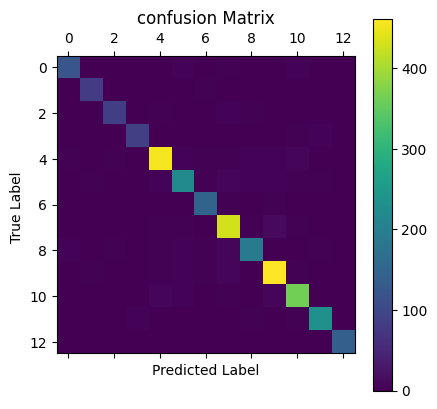

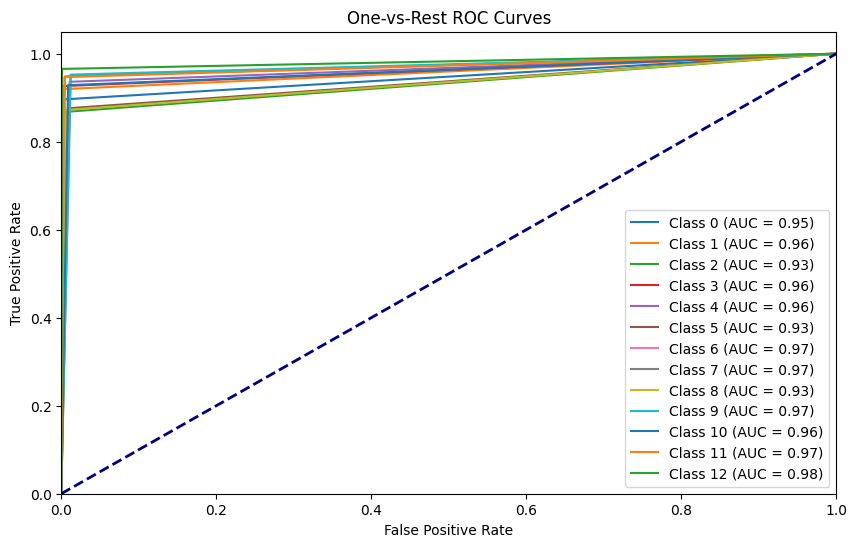

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

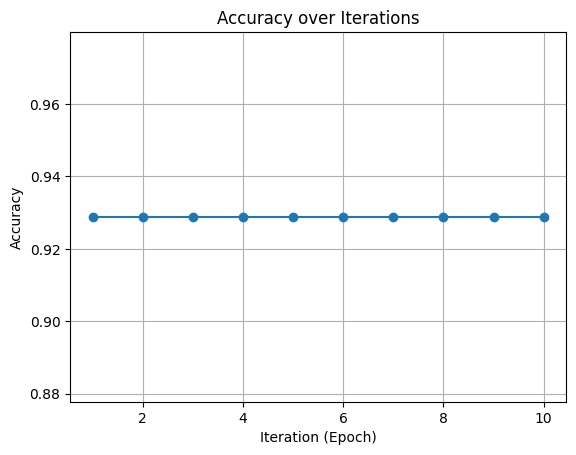

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

precision = precision_score(y_test, ensemble_predictions1, average='weighted')
recall = recall_score(y_test, ensemble_predictions1, average='weighted')
f1 = f1_score(y_test, ensemble_predictions1, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions1)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions1) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions1]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions1)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions1, y_test)
    
    # Make ensemble predictions
    ensemble_predictions1 = meta_learner.predict(combined_predictions1)
    
    # Calculate accuracy
    ensemble_accuracy1 = accuracy_score(y_test, ensemble_predictions1)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy1)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()



DPN92+DenseNet121+FewShot

In [44]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions2, y_test)

# Make ensemble predictions
ensemble_predictions2 = meta_learner.predict(combined_predictions2)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions2)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9685670261941448


/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.9686575325854161
Recall: 0.9685670261941448
F1-score: 0.9685351110641484
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       135
           1       0.99      0.97      0.98        87
           2       1.00      0.97      0.98        98
           3       0.98      0.96      0.97        95
           4       0.97      0.97      0.97       486
           5       0.95      0.95      0.95       250
           6       0.95      0.93      0.94       157
           7       0.96      0.97      0.97       453
           8       0.96      0.95      0.96       219
           9       0.97      0.98      0.97       485
          10       0.97      0.98      0.98       391
          11       0.98      0.99      0.99       244
          12       1.00      0.99      1.00       145

    accuracy                           0.97      3245
   macro avg       0.97      0.96      0.97      3245
weighted avg       0.97  

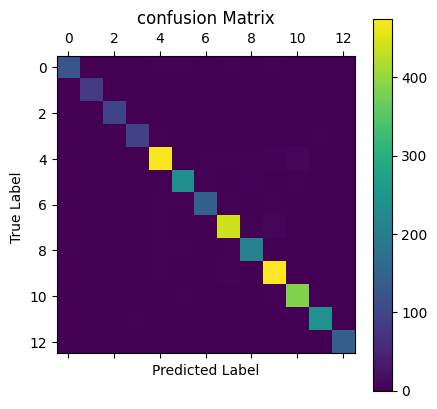

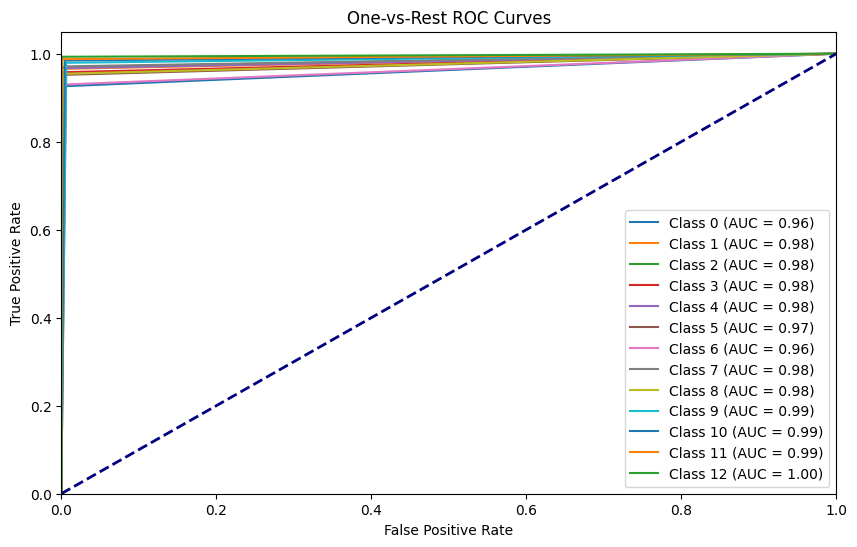

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

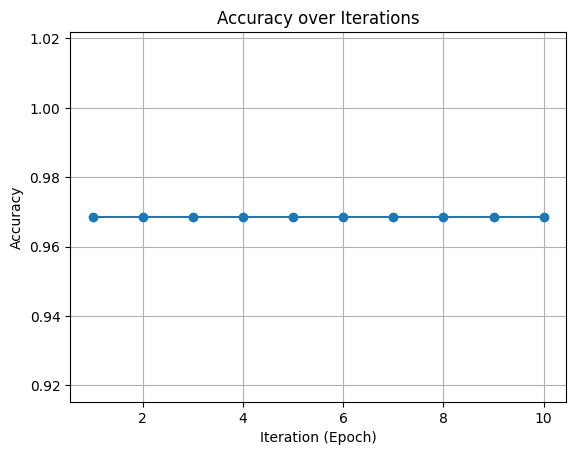

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

precision = precision_score(y_test, ensemble_predictions2, average='weighted')
recall = recall_score(y_test, ensemble_predictions2, average='weighted')
f1 = f1_score(y_test, ensemble_predictions2, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions2)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions2) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions2]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions2)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions2, y_test)
    
    # Make ensemble predictions
    ensemble_predictions2 = meta_learner.predict(combined_predictions2)
    
    # Calculate accuracy
    ensemble_accuracy2 = accuracy_score(y_test, ensemble_predictions2)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy2)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

